# 03 — Customer Segmentation Model

In [19]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')


## 1. Load Data

In [20]:

df = pd.read_csv('data/census_preprocessed.csv')
print("Shape:", df.shape)

WEIGHT_COL = 'weight'
TARGET = 'label_binary'

# Features only (drop label and weight for unsupervised)
feature_cols = [c for c in df.columns if c not in [TARGET, WEIGHT_COL]]
X = df[feature_cols].copy()
w = df[WEIGHT_COL].copy()
y = df[TARGET].copy()

print(f"Features used for segmentation: {X.shape[1]}")


Shape: (199523, 42)
Features used for segmentation: 40


## 2. Scale & PCA

Components to explain 90% variance: 26


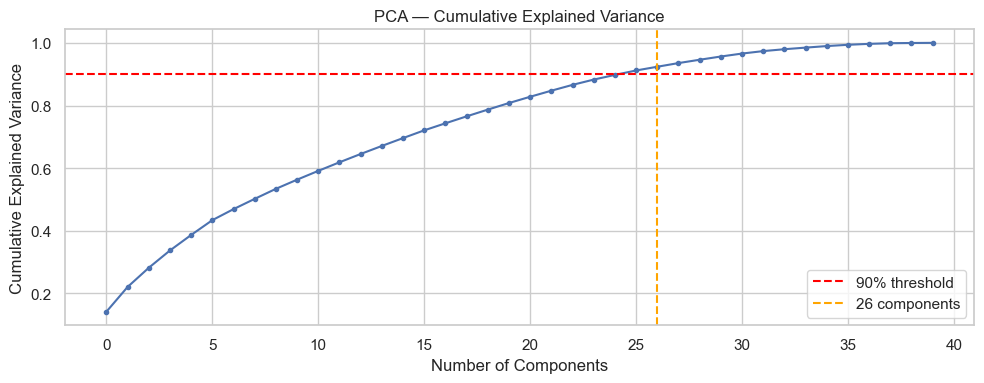

In [21]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for visualization and noise reduction
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# Explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_90 = np.argmax(cumvar >= 0.90) + 1
print(f"Components to explain 90% variance: {n_comp_90}")

plt.figure(figsize=(10, 4))
plt.plot(cumvar, marker='o', markersize=3)
plt.axhline(0.90, color='red', linestyle='--', label='90% threshold')
plt.axvline(n_comp_90, color='orange', linestyle='--', label=f'{n_comp_90} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.savefig('figures/fig_pca_variance.png', dpi=100)
plt.show()


In [22]:

# Use top components for clustering (balance info vs noise)
N_COMPONENTS = min(n_comp_90, 20)
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Using {N_COMPONENTS} PCA components, explaining {pca.explained_variance_ratio_.sum()*100:.1f}% variance")


Using 20 PCA components, explaining 80.8% variance


## 3. Choose K — Elbow + Silhouette

k=2: inertia=5600849, silhouette=0.1659
k=3: inertia=5143005, silhouette=0.1553
k=4: inertia=4973302, silhouette=0.1510
k=5: inertia=4673363, silhouette=0.1702
k=6: inertia=4254841, silhouette=0.1744
k=7: inertia=4258603, silhouette=0.1602
k=8: inertia=3926951, silhouette=0.1957
k=9: inertia=3736365, silhouette=0.1890


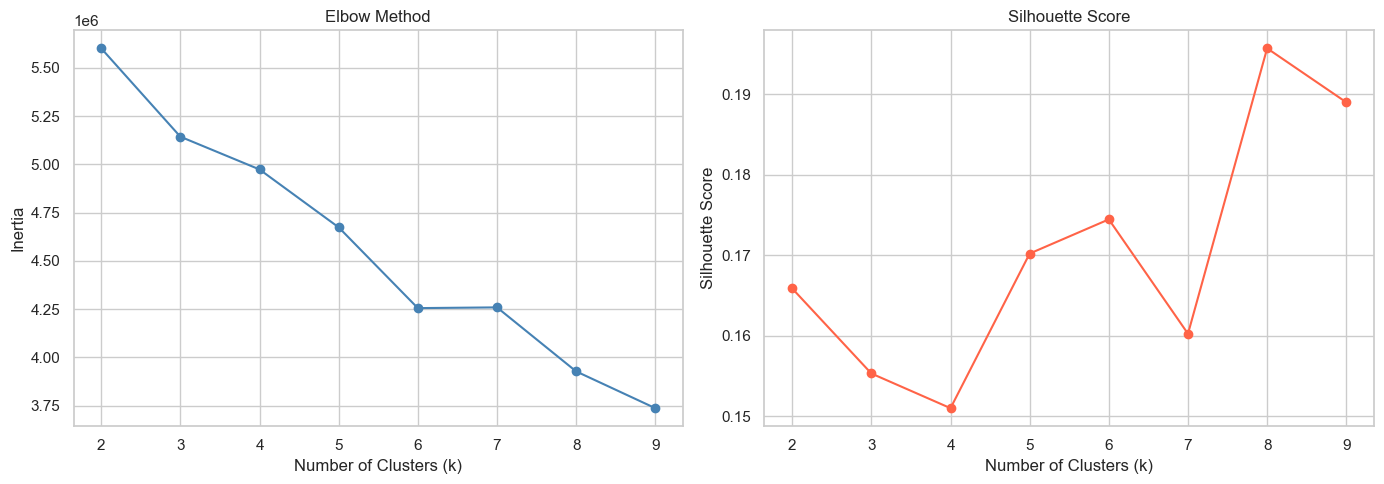

In [23]:

K_range = range(2, 10)
inertias = []
sil_scores = []

# Use a sample for silhouette (expensive on full 200k)
sample_idx = np.random.choice(len(X_pca), size=10000, replace=False)
X_sample = X_pca[sample_idx]

for k in K_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=5, batch_size=5000)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    labels_sample = km.predict(X_sample)
    sil = silhouette_score(X_sample, labels_sample, sample_size=5000, random_state=42)
    sil_scores.append(sil)
    print(f"k={k}: inertia={km.inertia_:.0f}, silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, 'o-', color='steelblue')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(K_range), sil_scores, 'o-', color='tomato')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.savefig('figures/fig_kmeans_selection.png', dpi=100)
plt.show()


## 4. Final K-Means Model

In [24]:

# Choose k based on elbow + silhouette (typically 4-5 for this dataset)
BEST_K = 4

km_final = MiniBatchKMeans(n_clusters=BEST_K, random_state=42, n_init=10, batch_size=5000)
df['cluster'] = km_final.fit_predict(X_pca)

print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())
print("\nWeighted cluster sizes (population-representative):")
weighted_sizes = df.groupby('cluster')[WEIGHT_COL].sum()
print((weighted_sizes / weighted_sizes.sum() * 100).round(1).astype(str) + '%')


Cluster sizes:
cluster
0    57070
1    86298
2    40739
3    15416
Name: count, dtype: int64

Weighted cluster sizes (population-representative):
cluster
0    28.0%
1    44.8%
2    20.5%
3     6.8%
Name: weight, dtype: object


## 5. PCA 2D Visualization

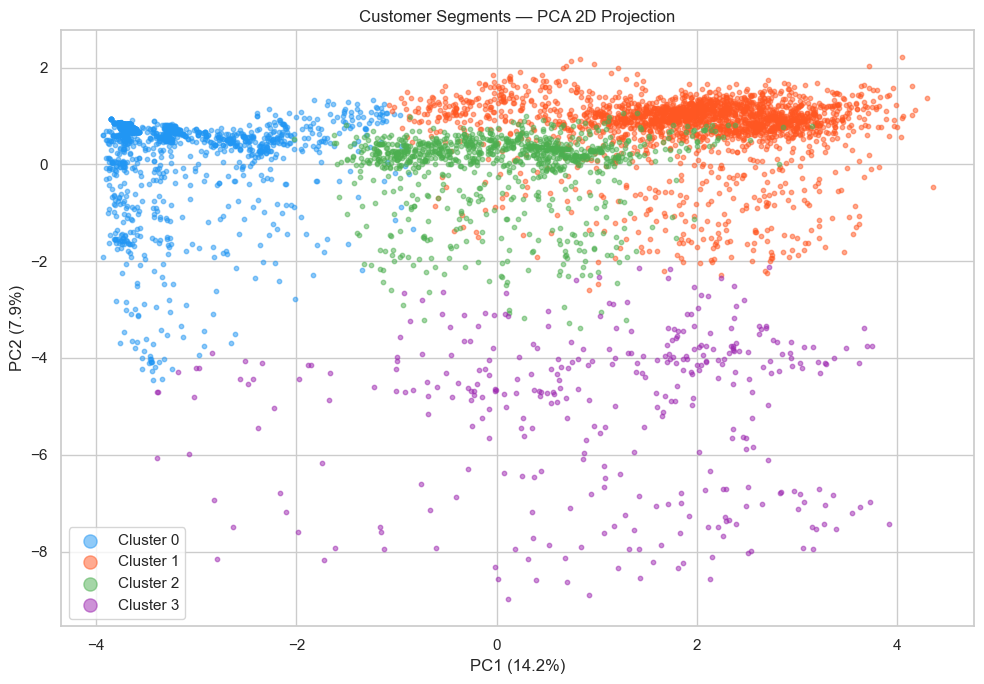

In [25]:

# Project to 2D for visualization
pca2d = PCA(n_components=2, random_state=42)
X_2d = pca2d.fit_transform(X_scaled)

sample_n = 5000
idx = np.random.choice(len(X_2d), sample_n, replace=False)
colors = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#00BCD4']

plt.figure(figsize=(10, 7))
for c in range(BEST_K):
    mask = df['cluster'].values[idx] == c
    plt.scatter(X_2d[idx][mask, 0], X_2d[idx][mask, 1],
                c=colors[c], label=f'Cluster {c}', alpha=0.5, s=10)
plt.xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Customer Segments — PCA 2D Projection')
plt.legend(markerscale=3)
plt.tight_layout()
plt.savefig('figures/fig_clusters_2d.png', dpi=100)
plt.show()


## 6. Cluster Profiling

In [26]:

# Re-attach original (encoded) features for profiling
profile_cols_num = ['age', 'education', 'wage per hour', 'capital gains',
                    'capital losses', 'dividends from stocks',
                    'weeks worked in year', 'num persons worked for employer']
profile_cols_num = [c for c in profile_cols_num if c in df.columns]

# Weighted mean per cluster for numerical features
def weighted_mean(group, weight_col):
    return (group[profile_cols_num].multiply(group[weight_col], axis=0)).sum() / group[weight_col].sum()

cluster_profiles = df.groupby('cluster').apply(lambda g: weighted_mean(g, WEIGHT_COL))
print("Weighted cluster means (numerical features):")
print(cluster_profiles.round(2))


Weighted cluster means (numerical features):
           age  education  wage per hour  capital gains  capital losses  \
cluster                                                                   
0         9.39       9.24           0.98           4.76            2.46   
1        38.40      11.14         120.25         823.80           67.48   
2        58.54       9.39           0.91         244.45           25.83   
3        39.30       8.71          45.07         313.58           34.90   

         dividends from stocks  weeks worked in year  \
cluster                                                
0                         7.91                  0.97   
1                       196.24                 46.13   
2                       493.38                  3.75   
3                        94.42                 27.82   

         num persons worked for employer  
cluster                                   
0                                   0.18  
1                                   3.


Weighted % earning >50K per cluster:
cluster
0     0.0
1    12.4
2     2.4
3     5.4
dtype: float64


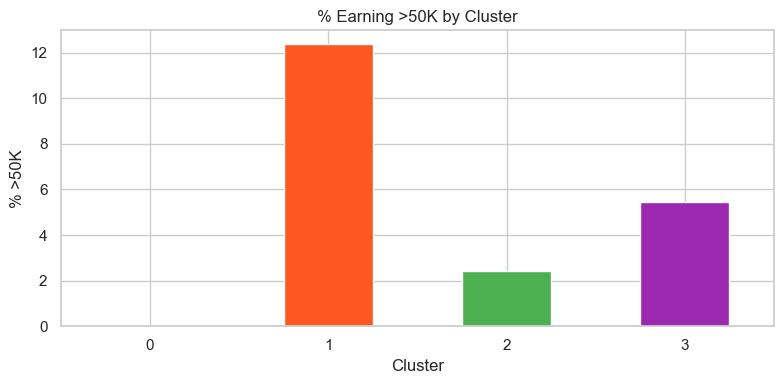

In [27]:

# Income rate per cluster (weighted)
income_rate = df.groupby('cluster').apply(
    lambda g: np.average(g[TARGET], weights=g[WEIGHT_COL]) * 100
)
print("\nWeighted % earning >50K per cluster:")
print(income_rate.round(1))

plt.figure(figsize=(8, 4))
income_rate.plot(kind='bar', color=colors[:BEST_K], edgecolor='white')
plt.title('% Earning >50K by Cluster')
plt.xlabel('Cluster')
plt.ylabel('% >50K')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/fig_cluster_income.png', dpi=100)
plt.show()


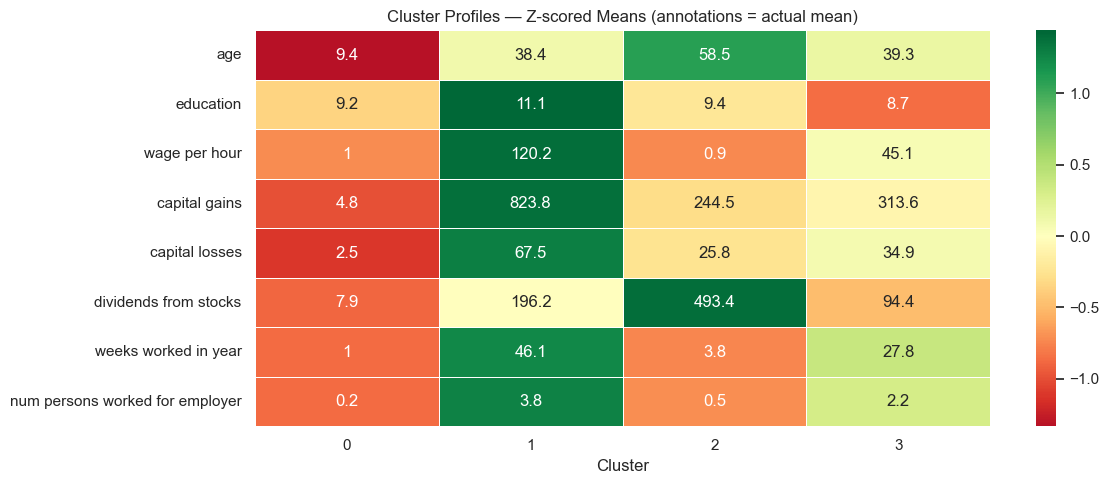

In [28]:

# Heatmap of cluster profiles
fig, ax = plt.subplots(figsize=(12, 5))
profile_norm = (cluster_profiles - cluster_profiles.mean()) / (cluster_profiles.std() + 1e-9)
sns.heatmap(profile_norm.T, annot=cluster_profiles.T.round(1), fmt='g',
            cmap='RdYlGn', center=0, ax=ax, linewidths=0.5)
ax.set_title('Cluster Profiles — Z-scored Means (annotations = actual mean)')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.savefig('figures/fig_cluster_heatmap.png', dpi=100)
plt.show()


## 7. Segment Descriptions & Business Recommendations

In [29]:

print("""
Based on weighted cluster profiles and income rates:

Cluster 0 — Children / Non-Working (28.0% of population)
  Avg age: ~9 years. Represents minors and non-labor-force participants.
  Wage: ~$1/hr  |  Capital gains: ~$5  |  Income >50K: 0.0%
  Marketing angle: Not a direct target; reach via parents (Cluster 1/2).
  Relevant for: children's products, education savings plans, family offers.

Cluster 1 — Prime Working Adults (44.8% of population)  [LARGEST SEGMENT]
  Avg age: 38 years. Full-time workers with meaningful investment income.
  Wage: ~$120/hr  |  Capital gains: ~$824  |  Income >50K: 12.4%
  Marketing angle: PRIMARY acquisition target for premium retail.
  Relevant for: luxury goods, investment products, travel, career development.

Cluster 2 — Older / Near-Retirement Adults (20.5% of population)
  Avg age: 58.5 years. Low wages but notable dividends ($493/yr avg).
  Wage: ~$1/hr  |  Capital gains: ~$244  |  Income >50K: 2.4%
  Note: Low current income may mask significant accumulated net worth.
  Relevant for: retirement planning, health & wellness, leisure/travel.

Cluster 3 — Mid-Career Moderate Earners (6.8% of population)
  Avg age: 39 years. Works part-year; lower wages than Cluster 1.
  Wage: ~$45/hr  |  Capital gains: ~$314  |  Income >50K: 5.4%
  Likely includes part-time workers, self-employed, or career-changers.
  Relevant for: mid-market retail, financial education, flexible benefit products.

=== Strategic Recommendations ===

1. COMBINE with classifier: Score each individual with the classifier and
   cross-reference with their cluster. Cluster 1 members with classifier
   score >0.25 are the highest-value targets for premium outreach.

2. Cluster 1 (44.8%) is the dominant addressable segment — broad campaigns
   here are cost-effective AND reach the highest concentration of >50K earners.

3. Cluster 2 has low income rate but high dividend income, suggesting hidden
   wealth. Suitable for net-worth-based (vs income-based) product targeting.

4. Cluster 0 (children) can be reached indirectly via Cluster 1/2 parents —
   family bundle messaging is the right channel.

5. Re-run segmentation annually as economic conditions shift.
""")



Based on weighted cluster profiles and income rates:

Cluster 0 — Children / Non-Working (28.0% of population)
  Avg age: ~9 years. Represents minors and non-labor-force participants.
  Wage: ~$1/hr  |  Capital gains: ~$5  |  Income >50K: 0.0%
  Marketing angle: Not a direct target; reach via parents (Cluster 1/2).
  Relevant for: children's products, education savings plans, family offers.

Cluster 1 — Prime Working Adults (44.8% of population)  [LARGEST SEGMENT]
  Avg age: 38 years. Full-time workers with meaningful investment income.
  Wage: ~$120/hr  |  Capital gains: ~$824  |  Income >50K: 12.4%
  Marketing angle: PRIMARY acquisition target for premium retail.
  Relevant for: luxury goods, investment products, travel, career development.

Cluster 2 — Older / Near-Retirement Adults (20.5% of population)
  Avg age: 58.5 years. Low wages but notable dividends ($493/yr avg).
  Wage: ~$1/hr  |  Capital gains: ~$244  |  Income >50K: 2.4%
  Note: Low current income may mask significant 

---\n## 8. Enhancement — Re-segmentation on Working-Age Population

In [30]:

# Cluster 0 (children, avg age ~9) creates an easy split that dominates the
# silhouette score. Here we re-cluster only the working-age population (age >= 16)
# and compare KMeans against a Gaussian Mixture Model (GMM).
# Original 4-cluster results above are unchanged.
from sklearn.mixture import GaussianMixture

df_work = df[df['age'] >= 16].copy()
w_work = df_work[WEIGHT_COL]
y_work = df_work[TARGET]
X_work = df_work[feature_cols].copy()

print(f"Full dataset:          {len(df):,} records")
print(f"Working-age (age>=16): {len(df_work):,} records")
print(f"Excluded (children):   {len(df)-len(df_work):,} records ({(1-len(df_work)/len(df))*100:.1f}%)")
print(f"Working-age >50K rate: {y_work.mean()*100:.1f}%")


Full dataset:          199,523 records
Working-age (age>=16): 149,175 records
Excluded (children):   50,348 records (25.2%)
Working-age >50K rate: 8.3%


In [31]:

scaler_w = StandardScaler()
X_work_scaled = scaler_w.fit_transform(X_work)

pca_w = PCA(n_components=20, random_state=42)
X_work_pca = pca_w.fit_transform(X_work_scaled)
print(f"PCA 20 components explain {pca_w.explained_variance_ratio_.sum()*100:.1f}% variance (working-age)")


PCA 20 components explain 79.7% variance (working-age)


k=2: KMeans sil=0.1208  |  GMM sil=0.3015
k=3: KMeans sil=0.1061  |  GMM sil=0.0330
k=4: KMeans sil=0.1189  |  GMM sil=0.0881
k=5: KMeans sil=0.1258  |  GMM sil=0.0927
k=6: KMeans sil=0.1246  |  GMM sil=0.0715
k=7: KMeans sil=0.1079  |  GMM sil=0.0486
k=8: KMeans sil=0.1476  |  GMM sil=0.0614


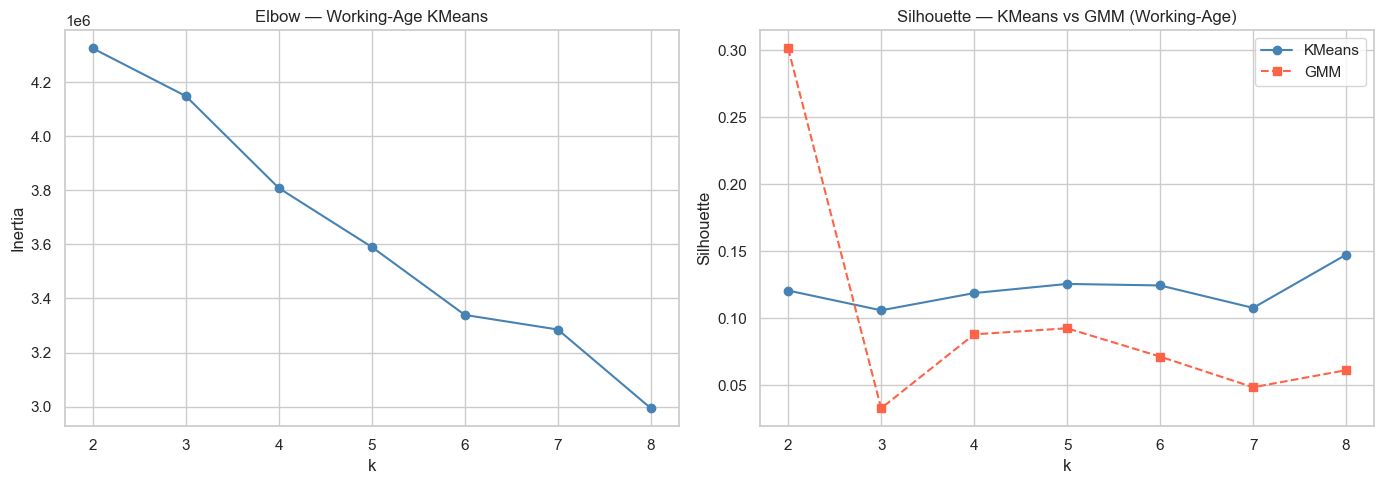

In [32]:

K_range2 = range(2, 9)
inertias2, sil_km2, sil_gmm2 = [], [], []

sample_idx2 = np.random.choice(len(X_work_pca), size=10000, replace=False)
X_sample2 = X_work_pca[sample_idx2]

for k in K_range2:
    km2 = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=5, batch_size=5000)
    km2.fit(X_work_pca)
    inertias2.append(km2.inertia_)
    lbl_km = km2.predict(X_sample2)
    sil_km2.append(silhouette_score(X_sample2, lbl_km, sample_size=5000, random_state=42))

    gmm = GaussianMixture(n_components=k, covariance_type='diag', random_state=42, max_iter=100)
    gmm.fit(X_work_pca)
    lbl_gmm = gmm.predict(X_sample2)
    sil_gmm2.append(silhouette_score(X_sample2, lbl_gmm, sample_size=5000, random_state=42))

    print(f"k={k}: KMeans sil={sil_km2[-1]:.4f}  |  GMM sil={sil_gmm2[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range2), inertias2, 'o-', color='steelblue')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow — Working-Age KMeans')
axes[1].plot(list(K_range2), sil_km2, 'o-', color='steelblue', label='KMeans')
axes[1].plot(list(K_range2), sil_gmm2, 's--', color='tomato', label='GMM')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
axes[1].set_title('Silhouette — KMeans vs GMM (Working-Age)')
axes[1].legend()
plt.tight_layout()
plt.savefig('figures/fig_enhance_kselection.png', dpi=100)
plt.show()


In [33]:

best_k2 = list(K_range2)[int(np.argmax(sil_km2))]
best_k_gmm = list(K_range2)[int(np.argmax(sil_gmm2))]
print(f"Best KMeans k: {best_k2}  (silhouette={max(sil_km2):.4f})")
print(f"Best GMM k:    {best_k_gmm}  (silhouette={max(sil_gmm2):.4f})")

km_work = MiniBatchKMeans(n_clusters=best_k2, random_state=42, n_init=10, batch_size=5000)
df_work['cluster_km'] = km_work.fit_predict(X_work_pca)

gmm_final = GaussianMixture(n_components=best_k_gmm, covariance_type='diag', random_state=42, max_iter=200)
gmm_final.fit(X_work_pca)
df_work['cluster_gmm'] = gmm_final.predict(X_work_pca)

print("\nKMeans cluster sizes (working-age):")
print(df_work['cluster_km'].value_counts().sort_index())
print("\nGMM cluster sizes (working-age):")
print(df_work['cluster_gmm'].value_counts().sort_index())


Best KMeans k: 8  (silhouette=0.1476)
Best GMM k:    2  (silhouette=0.3015)

KMeans cluster sizes (working-age):
cluster_km
0    33824
1    20216
2    12526
3     3725
4    24593
5    22021
6     6784
7    25486
Name: count, dtype: int64

GMM cluster sizes (working-age):
cluster_gmm
0     24341
1    124834
Name: count, dtype: int64


In [34]:

profile_cols2 = ['age', 'education', 'wage per hour', 'capital gains',
                 'dividends from stocks', 'weeks worked in year',
                 'num persons worked for employer']
profile_cols2 = [c for c in profile_cols2 if c in df_work.columns]

def weighted_mean2(df_g, wcol, pcols):
    return (df_g[pcols].multiply(df_g[wcol], axis=0)).sum() / df_g[wcol].sum()

print("=== KMeans profiles (working-age) ===")
km_prof = df_work.groupby('cluster_km').apply(lambda g: weighted_mean2(g, WEIGHT_COL, profile_cols2))
km_income = df_work.groupby('cluster_km').apply(
    lambda g: np.average(g[TARGET], weights=g[WEIGHT_COL]) * 100)
km_share = df_work.groupby('cluster_km')[WEIGHT_COL].sum()
km_share = (km_share / km_share.sum() * 100).round(1)
km_prof['% >50K'] = km_income.round(1)
km_prof['pop_share%'] = km_share
print(km_prof.round(2))

print("\n=== GMM profiles (working-age) ===")
gmm_prof = df_work.groupby('cluster_gmm').apply(lambda g: weighted_mean2(g, WEIGHT_COL, profile_cols2))
gmm_income = df_work.groupby('cluster_gmm').apply(
    lambda g: np.average(g[TARGET], weights=g[WEIGHT_COL]) * 100)
gmm_share = df_work.groupby('cluster_gmm')[WEIGHT_COL].sum()
gmm_share = (gmm_share / gmm_share.sum() * 100).round(1)
gmm_prof['% >50K'] = gmm_income.round(1)
gmm_prof['pop_share%'] = gmm_share
print(gmm_prof.round(2))


=== KMeans profiles (working-age) ===
              age  education  wage per hour  capital gains  \
cluster_km                                                   
0           36.96      10.90         108.05        1112.43   
1           58.56       9.39           0.09         237.68   
2           41.94       8.70          48.62         345.02   
3           34.16      10.61          62.68         494.95   
4           38.68      10.94         129.63        1200.65   
5           50.98       8.30           1.00         171.55   
6           33.63      10.17          74.13         340.50   
7           41.55      11.43         115.69          40.12   

            dividends from stocks  weeks worked in year  \
cluster_km                                                
0                          214.12                 44.58   
1                          454.11                  1.81   
2                          108.16                 29.44   
3                          158.00             

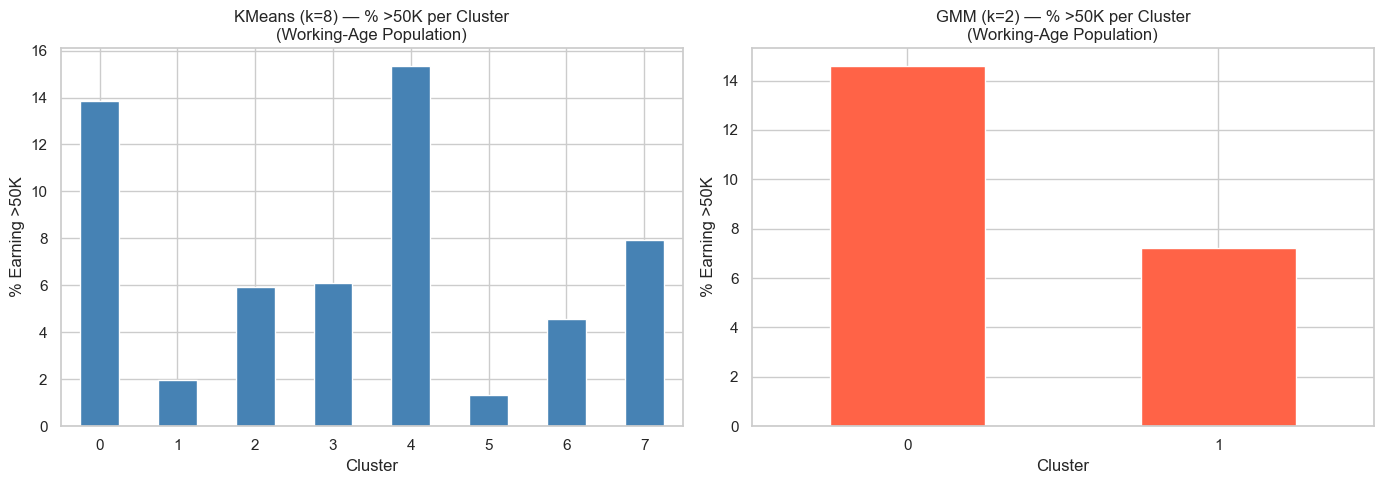

In [35]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
km_income.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title(f'KMeans (k={best_k2}) — % >50K per Cluster\n(Working-Age Population)')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('% Earning >50K')
axes[0].tick_params(rotation=0)

gmm_income.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title(f'GMM (k={best_k_gmm}) — % >50K per Cluster\n(Working-Age Population)')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('% Earning >50K')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig('figures/fig_enhance_income.png', dpi=100)
plt.show()


In [36]:

sil_original = sil_scores[2]  # k=4, index 2 in K_range(2..9)
print("=== Silhouette Score Comparison ===")
print(f"Original  KMeans k=4  (full data, incl. children): {sil_original:.4f}")
print(f"Enhanced  KMeans k={best_k2}  (working-age only):        {max(sil_km2):.4f}")
print(f"Enhanced  GMM    k={best_k_gmm}  (working-age only):        {max(sil_gmm2):.4f}")
print(f"\nKMeans improved: {max(sil_km2) > sil_original}")
print(f"GMM improved:    {max(sil_gmm2) > sil_original}")


=== Silhouette Score Comparison ===
Original  KMeans k=4  (full data, incl. children): 0.1510
Enhanced  KMeans k=8  (working-age only):        0.1476
Enhanced  GMM    k=2  (working-age only):        0.3015

KMeans improved: False
GMM improved:    True
